Hey Claude! Provide a workflow for earthquakes location and multi-station picking of seismic arrivals. Provide code to deploy in a local computer using python interface in a Jupyter notebook.

## Earthquake location & Multi-Station Seismic Phase Picking

### Required packages

In [2]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install seisbench
!pip install xdas # added this 

Looking in indexes: https://download.pytorch.org/whl/cpu


### Imports and Setup

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# ObsPy
from obspy import UTCDateTime, Stream, Inventory
from obspy.clients.fdsn import Client
from obspy.signal.trigger import recursive_sta_lta, trigger_onset
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees, degrees2kilometers

# SeisBench for ML-based picking
try:
    import seisbench.models as sbm
    SEISBENCH_AVAILABLE = True
    print("SeisBench available ✓")
except ImportError:
    SEISBENCH_AVAILABLE = False
    print("SeisBench not installed – using STA/LTA fallback picker")

print("All imports successful ✓")

SeisBench available ✓
All imports successful ✓


### Configuration -- Edit These Parameters

In [35]:
# ─── Target event (approximate, for waveform window) ───────────────────────
# 61 km NNE of Miches, D.R.
ORIGIN_TIME  = UTCDateTime("2026-02-21T01:44:26")
EVT_LAT      = 19.50
EVT_LON      = -68.83
EVT_DEPTH_KM = 10.0

# ─── Station search box ────────────────────────────────────────────────────
NET      = "LO"          # AFAD Turkey network  (use * for all)
STA      = "*"           # all stations
LOC      = "*"
# CHA      = "HH?,BH?"     # broadband channels
CHA = "EH?"  # tipical chan for loyola
MAX_DIST_DEG = 3.0       # stations within this epicentral distance

# ─── Time window ──────────────────────────────────────────────────────────
PRE_S  = 60              # seconds before origin
POST_S = 300             # seconds after origin

# ─── Data client ──────────────────────────────────────────────────────────
FDSN_CLIENT = "IRIS"     # options: IRIS, GEOFON, ORFEUS, ETH, etc.

# ─── Velocity model for travel times ──────────────────────────────────────
VELOCITY_MODEL = "iasp91"  # or "ak135", "1066a"

# ─── Picker settings ──────────────────────────────────────────────────────
ML_MODEL     = "PhaseNet"  # or "EQTransformer", "GPD"
ML_THRESHOLD_P = 0.3
ML_THRESHOLD_S = 0.3

# STA/LTA fallback
STALTA_STA   = 0.5    # s
STALTA_LTA   = 10.0   # s
STALTA_ON    = 3.5
STALTA_OFF   = 1.5

print("Configuration set ✓")

Configuration set ✓


### Data Acquisition

In [36]:
client = Client(FDSN_CLIENT)

t_start = ORIGIN_TIME - PRE_S
t_end   = ORIGIN_TIME + POST_S

# ── Get station inventory within MAX_DIST_DEG ────────────────────────────
print(f"Querying stations from {FDSN_CLIENT}...")
try:
    inventory = client.get_stations(
        network=NET, station=STA, location=LOC, channel=CHA,
        starttime=t_start, endtime=t_end,
        latitude=EVT_LAT, longitude=EVT_LON, maxradius=MAX_DIST_DEG,
        level="response"
    )
    print(f"Found {len(inventory.networks)} network(s), "
          f"{sum(len(n) for n in inventory)} station(s)")
except Exception as e:
    print(f"Station query failed: {e}")
    inventory = None

# ── Download waveforms ───────────────────────────────────────────────────
print("Downloading waveforms...")
try:
    st_raw = client.get_waveforms(
        network=NET, station=STA, location=LOC, channel=CHA,
        starttime=t_start, endtime=t_end
    )
    print(f"Downloaded {len(st_raw)} traces")
except Exception as e:
    print(f"Waveform download failed: {e}")
    # Load from local miniseed for offline use:
    # st_raw = read("local_data/*.mseed")
    st_raw = Stream()

Querying stations from IRIS...
Found 1 network(s), 13 station(s)
Downloaded 33 traces


### Preprocessing

In [37]:
def preprocess(st, inventory=None, freqmin=1.0, freqmax=20.0, decimate_to=100):
    """Standard seismic preprocessing pipeline."""
    st_proc = st.copy()
    
    # 1. Merge (handle gaps)
    st_proc.merge(method=1, fill_value='interpolate')
    
    # 2. Detrend & taper
    st_proc.detrend('demean')
    st_proc.detrend('linear')
    st_proc.taper(max_percentage=0.05, type='cosine')
    
    # 3. Remove instrument response → velocity (m/s)
    if inventory is not None:
        try:
            st_proc.remove_response(inventory=inventory, output='VEL',
                                    pre_filt=(0.5, 1.0, 45.0, 50.0))
            print("Instrument response removed ✓")
        except Exception as e:
            print(f"Response removal skipped: {e}")
    
    # 4. Bandpass filter
    st_proc.filter('bandpass', freqmin=freqmin, freqmax=freqmax, corners=4, zerophase=True)
    
    # 5. Resample if needed
    for tr in st_proc:
        if tr.stats.sampling_rate > decimate_to:
            factor = int(tr.stats.sampling_rate / decimate_to)
            tr.decimate(factor, no_filter=False)
    
    return st_proc


st_proc = preprocess(st_raw, inventory=inventory, freqmin=1.0, freqmax=20.0)
print(f"Preprocessed: {len(st_proc)} traces ready")

Response removal skipped: No matching response information found.
Preprocessed: 33 traces ready


### Phase Picking - ML Based (Seisbench/PhaseNet)

In [38]:
all_picks = []   # will collect dicts: {net, sta, cha, phase, time, prob}

if SEISBENCH_AVAILABLE and len(st_proc) > 0:
    print(f"Loading {ML_MODEL} model...")
    
    if ML_MODEL == "PhaseNet":
        model = sbm.PhaseNet.from_pretrained("stead")
    elif ML_MODEL == "EQTransformer":
        model = sbm.EQTransformer.from_pretrained("stead")
    elif ML_MODEL == "GPD":
        model = sbm.GPD.from_pretrained("stead")
    else:
        raise ValueError(f"Unknown model: {ML_MODEL}")
    
    model.eval()
    print(f"{ML_MODEL} loaded ✓")
    
    # ── Run picker per station (3-component groups) ──────────────────────
    stations_in_stream = set(f"{tr.stats.network}.{tr.stats.station}" for tr in st_proc)
    
    for sta_key in stations_in_stream:
        net_code, sta_code = sta_key.split('.')
        st_sta = st_proc.select(network=net_code, station=sta_code)
        
        if len(st_sta) == 0:
            continue
        
        try:
            # SeisBench annotate returns a stream of probability traces
            annotations = model.annotate(st_sta)
            
            # Extract picks above threshold
            output = model.classify(
                st_sta,
                P_threshold=ML_THRESHOLD_P,
                S_threshold=ML_THRESHOLD_S
            )
            picks = output.picks
            
            for pk in picks:
                all_picks.append({
                    'network'  : net_code,
                    'station'  : sta_code,
                    'phase'    : pk.phase,
                    'time'     : pk.peak_time,
                    'prob'     : pk.peak_value,
                    'method'   : ML_MODEL
                })
            
            print(f"  {sta_key}: {len(picks)} picks")
        
        except Exception as e:
            print(f"  {sta_key}: picking failed → {e}")
    
    print(f"\nTotal ML picks: {len(all_picks)}")
else:
    print("Skipping ML picking (SeisBench unavailable or no data)")

Loading PhaseNet model...
PhaseNet loaded ✓
  LO.LOVI: 1 picks
  LO.LOBH: 1 picks
  LO.LOMC: 0 picks
  LO.LOPU: 2 picks
  LO.LOTA: 2 picks
  LO.LOSA: 2 picks
  LO.LONE3: 0 picks
  LO.LONA2: 1 picks
  LO.LOCA: 2 picks
  LO.LOLU: 1 picks
  LO.LORA: 1 picks

Total ML picks: 13


### Phase Picking - Classical STA/LTA Fallback

In [39]:
def stalta_picks(st, sta_s=0.5, lta_s=10.0, thr_on=3.5, thr_off=1.5):
    """
    Classic STA/LTA P-picker. Returns list of pick dicts.
    Uses Z component preferentially.
    """
    picks = []
    stations = set(f"{tr.stats.network}.{tr.stats.station}" for tr in st)
    
    for sta_key in stations:
        net_code, sta_code = sta_key.split('.')
        
        # prefer Z/vertical component
        tr_z = None
        for comp in ['Z', 'E', 'N', '1', '2', '3']:
            candidates = st.select(network=net_code, station=sta_code, component=comp)
            if len(candidates) > 0:
                tr_z = candidates[0]
                break
        
        if tr_z is None:
            continue
        
        df = tr_z.stats.sampling_rate
        cft = recursive_sta_lta(tr_z.data, int(sta_s * df), int(lta_s * df))
        triggers = trigger_onset(cft, thr_on, thr_off)
        
        for trig in triggers:
            pick_time = tr_z.stats.starttime + trig[0] / df
            picks.append({
                'network' : net_code,
                'station' : sta_code,
                'phase'   : 'P',
                'time'    : pick_time,
                'prob'    : float(cft[trig[0]]),   # cft value as pseudo-prob
                'method'  : 'STA/LTA'
            })
    
    return picks

# SEISBENCH_AVAILABLE = False

if not SEISBENCH_AVAILABLE and len(st_proc) > 0:
    all_picks = stalta_picks(st_proc, STALTA_STA, STALTA_LTA, STALTA_ON, STALTA_OFF)
    print(f"STA/LTA picks: {len(all_picks)}")
elif SEISBENCH_AVAILABLE and len(all_picks) == 0:
    print("ML returned no picks, running STA/LTA as backup...")
    all_picks = stalta_picks(st_proc, STALTA_STA, STALTA_LTA, STALTA_ON, STALTA_OFF)

picks_df = pd.DataFrame(all_picks)
if len(picks_df) > 0:
    picks_df = picks_df.sort_values('time').reset_index(drop=True)
    print(picks_df[['network','station','phase','time','prob','method']].to_string(index=False))

network station phase                        time     prob   method
     LO    LOSA     P 2026-02-21T01:44:47.450000Z 0.771159 PhaseNet
     LO    LOPU     P 2026-02-21T01:44:57.220000Z 0.712266 PhaseNet
     LO    LOTA     P 2026-02-21T01:44:58.410000Z 0.933956 PhaseNet
     LO    LOCA     P 2026-02-21T01:45:01.260000Z 0.538013 PhaseNet
     LO    LOSA     S 2026-02-21T01:45:02.940000Z 0.379585 PhaseNet
     LO   LONA2     S 2026-02-21T01:45:10.280000Z 0.454686 PhaseNet
     LO    LOPU     S 2026-02-21T01:45:19.810000Z 0.775081 PhaseNet
     LO    LOTA     S 2026-02-21T01:45:21.510000Z 0.585911 PhaseNet
     LO    LOCA     S 2026-02-21T01:45:27.140000Z 0.637535 PhaseNet
     LO    LOVI     S 2026-02-21T01:45:31.630000Z 0.917475 PhaseNet
     LO    LOLU     S 2026-02-21T01:45:34.060000Z 0.445736 PhaseNet
     LO    LORA     S 2026-02-21T01:45:36.330000Z 0.346042 PhaseNet
     LO    LOBH     S 2026-02-21T01:45:38.110000Z 0.632491 PhaseNet


### Travel-Time Prediction (TauPy)

In [40]:
taup = TauPyModel(model=VELOCITY_MODEL)

def get_theoretical_arrivals(evt_lat, evt_lon, evt_depth_km,
                              sta_lat, sta_lon, phases=['P','S']):
    """
    Compute theoretical travel times using TauPy.
    Returns dict {phase: travel_time_s}
    """
    dist_deg = locations2degrees(evt_lat, evt_lon, sta_lat, sta_lon)
    arrivals = taup.get_travel_times(evt_depth_km, dist_deg, phase_list=phases)
    result = {}
    for arr in arrivals:
        if arr.name not in result:   # keep first (fastest)
            result[arr.name] = arr.time
    return dist_deg, result


# Compute for each station in inventory
theoretical = {}   # {sta_key: {dist_deg, P_time, S_time}}

if inventory is not None:
    for net in inventory:
        for sta in net:
            key = f"{net.code}.{sta.code}"
            dist_deg, tt = get_theoretical_arrivals(
                EVT_LAT, EVT_LON, EVT_DEPTH_KM,
                sta.latitude, sta.longitude
            )
            theoretical[key] = {
                'lat'     : sta.latitude,
                'lon'     : sta.longitude,
                'dist_deg': dist_deg,
                'dist_km' : degrees2kilometers(dist_deg),
                'P_tt_s'  : tt.get('P', None),
                'S_tt_s'  : tt.get('S', None),
                'P_abs'   : ORIGIN_TIME + tt['P'] if 'P' in tt else None,
                'S_abs'   : ORIGIN_TIME + tt['S'] if 'S' in tt else None,
            }

theo_df = pd.DataFrame(theoretical).T
print(theo_df[['dist_km','P_tt_s','S_tt_s']].to_string())

             dist_km     P_tt_s     S_tt_s
LO.LOCA   212.065287  32.549647   57.46292
LO.LODA2  301.292237  43.585177  77.310102
LO.LODU1  305.960796  44.162558  78.348421
LO.LOLU   231.904156  35.003413  61.876076
LO.LOMC   297.826472  43.156551  76.539293
LO.LONA2  109.330947  19.114487   33.04938
LO.LONE3  293.672286  42.642784  75.615374
LO.LOPU   181.407179  28.757819  50.642536
LO.LORA   266.800388  39.319453  69.638406
LO.LOSA    58.031739        NaN        NaN
LO.LOSCT  181.317836  28.746769   50.62266
LO.LOTA   183.338443  28.996695  51.072182
LO.LOVI   327.543454  46.831676  83.148382


### Simple Geiger-Style Earthquake Location
Interactive least-squares inversion of P-arrival residuals to refine hypocenter.

In [41]:
from scipy.optimize import minimize

def locate_earthquake(picks_df, theo_df, evt_lat0, evt_lon0, evt_depth0, origin_time0,
                      vp=6.0, vs=3.5, phase='P', max_residual_s=2.0):
    """
    Simplified Geiger-style location using scipy minimize.
    Uses a 1-D constant velocity model (can be swapped for TauPy).
    
    Parameters
    ----------
    picks_df   : DataFrame of observed picks
    theo_df    : DataFrame with station lat/lon
    phase      : 'P' or 'S'
    max_residual_s : reject picks with initial residual > this value
    
    Returns
    -------
    result dict with best lat, lon, depth, origin_time, rms
    """
    v = vp if phase == 'P' else vs
    
    # Filter picks to chosen phase & stations with known positions
    p_picks = picks_df[picks_df['phase'] == phase].copy()
    p_picks['sta_key'] = p_picks['network'] + '.' + p_picks['station']
    p_picks = p_picks[p_picks['sta_key'].isin(theo_df.index)]
    
    if len(p_picks) < 4:
        print(f"Need ≥4 {phase} picks for location, have {len(p_picks)}")
        return None
    
    # Observed arrival times as float (seconds from epoch)
    obs_times = np.array([float(t) for t in p_picks['time']])
    sta_lats   = np.array([theo_df.loc[k, 'lat'] for k in p_picks['sta_key']])
    sta_lons   = np.array([theo_df.loc[k, 'lon'] for k in p_picks['sta_key']])
    
    # Flat-earth distance approximation (km)
    def dist_km(lat1, lon1, lat2, lon2):
        dlat = (lat2 - lat1) * 111.195
        dlon = (lon2 - lon1) * 111.195 * np.cos(np.radians(lat1))
        return np.sqrt(dlat**2 + dlon**2)
    
    def objective(params):
        lat, lon, depth_km, t0 = params
        d_km = dist_km(lat, lon, sta_lats, sta_lons)
        hypo_dist = np.sqrt(d_km**2 + depth_km**2)
        tt_pred = hypo_dist / v
        t_pred  = t0 + tt_pred
        residuals = obs_times - t_pred
        return np.sum(residuals**2)
    
    x0 = [evt_lat0, evt_lon0, evt_depth0, float(origin_time0)]
    
    res = minimize(objective, x0,
                   method='Nelder-Mead',
                   options={'xatol':1e-4, 'fatol':1e-4, 'maxiter':10000})
    
    lat_f, lon_f, dep_f, t0_f = res.x
    
    # Compute final residuals
    from obspy import UTCDateTime as UTC
    origin_f = UTC(t0_f)
    d_km = dist_km(lat_f, lon_f, sta_lats, sta_lons)
    hypo_dist = np.sqrt(d_km**2 + dep_f**2)
    tt_pred = hypo_dist / v
    t_pred  = t0_f + tt_pred
    residuals = obs_times - t_pred
    rms = np.sqrt(np.mean(residuals**2))
    
    return {
        'lat'           : lat_f,
        'lon'           : lon_f,
        'depth_km'      : dep_f,
        'origin_time'   : origin_f,
        'rms_s'         : rms,
        'n_picks'       : len(p_picks),
        'residuals_s'   : residuals,
        'stations'      : list(p_picks['sta_key']),
    }


# Run location
if len(picks_df) >= 4 and len(theo_df) > 0:
    loc = locate_earthquake(picks_df, theo_df,
                            EVT_LAT, EVT_LON, EVT_DEPTH_KM, ORIGIN_TIME)
    if loc:
        print(f"\n{'='*50}")
        print(f"HYPOCENTER SOLUTION")
        print(f"  Latitude  : {loc['lat']:.4f}°")
        print(f"  Longitude : {loc['lon']:.4f}°")
        print(f"  Depth     : {loc['depth_km']:.1f} km")
        print(f"  Origin    : {loc['origin_time']}")
        print(f"  RMS       : {loc['rms_s']:.3f} s  (n={loc['n_picks']} picks)")
        print(f"{'='*50}")
else:
    print("Insufficient picks for location. Check data / picking thresholds.")
    loc = None


HYPOCENTER SOLUTION
  Latitude  : 19.3576°
  Longitude : -69.6150°
  Depth     : 9.6 km
  Origin    : 2026-02-21T01:44:40.476739Z
  RMS       : 0.645 s  (n=4 picks)


### Visualization

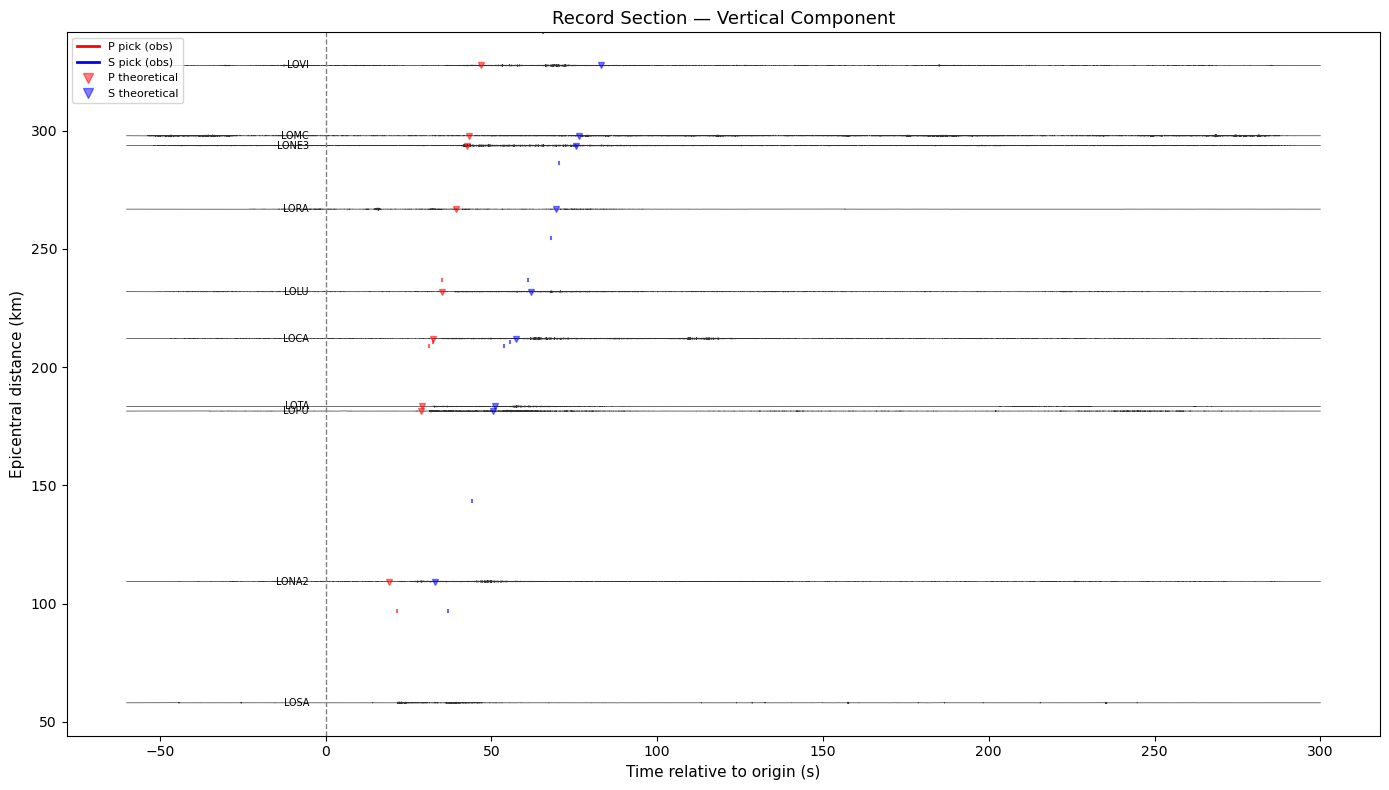

In [44]:
# ── 7A. Record Section (waveforms sorted by distance) ────────────────────

def plot_record_section(st, inventory, evt_lat, evt_lon, origin_time,
                        picks_df=None, theoretical=None,
                        freqmin=1.0, freqmax=10.0):
    
    if len(st) == 0:
        print("No data to plot")
        return
    
    # Collect Z traces with distances
    traces_dist = []
    for tr in st:
        if tr.stats.channel[-1] not in ('Z', 'z'):
            continue
        key = f"{tr.stats.network}.{tr.stats.station}"
        if key in theoretical:
            dist = theoretical[key]['dist_km']
            traces_dist.append((dist, key, tr))
    
    if not traces_dist:
        print("No Z traces with distance info found")
        return
    
    traces_dist.sort(key=lambda x: x[0])
    
    fig, ax = plt.subplots(figsize=(14, max(6, len(traces_dist)*0.8)))
    
    for i, (dist_km, key, tr) in enumerate(traces_dist):
        # Normalize
        data = tr.data.copy().astype(float)
        if np.max(np.abs(data)) > 0:
            data /= np.max(np.abs(data)) * 2
        
        times = tr.times(reftime=origin_time)
        ax.plot(times, data + dist_km, 'k', lw=0.5, alpha=0.8)
        ax.text(-5, dist_km, key.split('.')[1], ha='right', va='center', fontsize=7)
        
        # Plot picks
        if picks_df is not None:
            net_c, sta_c = key.split('.')
            sta_picks = picks_df[(picks_df['network']==net_c) & (picks_df['station']==sta_c)]
            for _, pk in sta_picks.iterrows():
                t_rel = float(pk['time']) - float(origin_time)
                color = 'red' if pk['phase'] == 'P' else 'blue'
                ax.axvline(x=t_rel, ymin=(dist_km-0.5)/max(d[0] for d in traces_dist),
                           ymax=(dist_km+0.5)/max(d[0] for d in traces_dist),
                           color=color, alpha=0.6, lw=1.5)
        
        # Theoretical arrivals
        if theoretical and key in theoretical:
            for ph, color in [('P', 'red'), ('S', 'blue')]:
                tt = theoretical[key].get(f'{ph}_tt_s')
                if tt:
                    ax.plot(tt, dist_km, marker='v', color=color, ms=5, alpha=0.5)
    
    ax.set_xlabel('Time relative to origin (s)', fontsize=11)
    ax.set_ylabel('Epicentral distance (km)', fontsize=11)
    ax.set_title('Record Section — Vertical Component', fontsize=13)
    ax.axvline(0, color='gray', ls='--', lw=1, label='Origin time')
    
    # Legend patches
    from matplotlib.lines import Line2D
    legend = [
        Line2D([0],[0], color='red',  lw=2, label='P pick (obs)'),
        Line2D([0],[0], color='blue', lw=2, label='S pick (obs)'),
        Line2D([0],[0], color='red',  marker='v', ls='', ms=7, alpha=0.5, label='P theoretical'),
        Line2D([0],[0], color='blue', marker='v', ls='', ms=7, alpha=0.5, label='S theoretical'),
    ]
    ax.legend(handles=legend, loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig('record_section.png', dpi=150)
    plt.show()


plot_record_section(st_proc, inventory, EVT_LAT, EVT_LON, ORIGIN_TIME,
                    picks_df=picks_df if len(picks_df)>0 else None,
                    theoretical=theoretical)

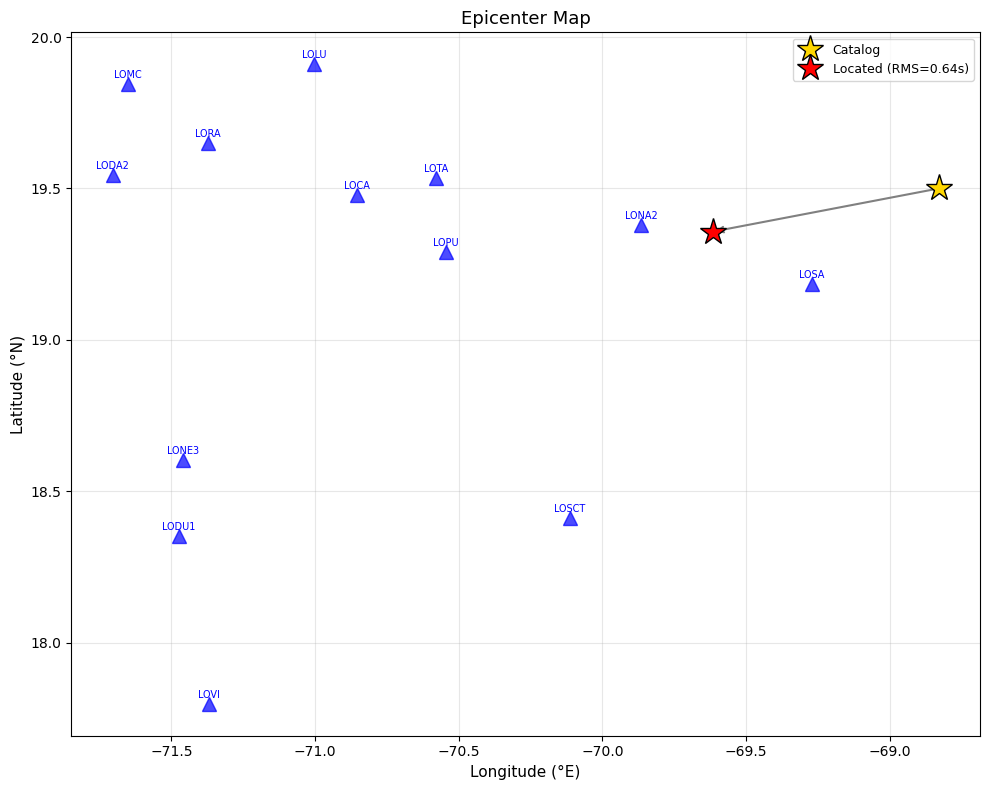

In [45]:
# ── 7B. Map: Event + Stations + Residuals ────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

# Plot stations
for key, info in theoretical.items():
    ax.plot(info['lon'], info['lat'], '^', color='blue', ms=10, alpha=0.7)
    ax.text(info['lon'], info['lat']+0.02, key.split('.')[1],
            ha='center', fontsize=7, color='blue')

# True (catalog) epicenter
ax.plot(EVT_LON, EVT_LAT, '*', color='gold', ms=20, mec='k', label='Catalog', zorder=5)

# Located epicenter
if loc:
    ax.plot(loc['lon'], loc['lat'], '*', color='red', ms=20, mec='k',
            label=f'Located (RMS={loc["rms_s"]:.2f}s)', zorder=6)
    ax.annotate('',
                xy=(loc['lon'], loc['lat']),
                xytext=(EVT_LON, EVT_LAT),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_xlabel('Longitude (°E)', fontsize=11)
ax.set_ylabel('Latitude (°N)', fontsize=11)
ax.set_title('Epicenter Map', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('epicenter_map.png', dpi=150)
plt.show()

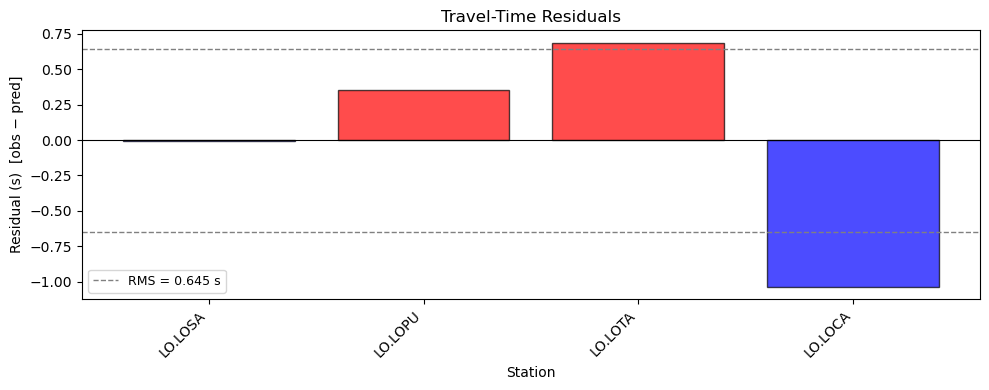

In [46]:
# ── 7C. Residual Bar Chart ────────────────────────────────────────────────

if loc and loc['residuals_s'] is not None:
    fig, ax = plt.subplots(figsize=(10, 4))
    stas = loc['stations']
    res  = loc['residuals_s']
    colors = ['red' if r > 0 else 'blue' for r in res]
    ax.bar(stas, res, color=colors, alpha=0.7, edgecolor='k')
    ax.axhline(0, color='k', lw=0.8)
    ax.axhline(loc['rms_s'], color='gray', ls='--', lw=1, label=f'RMS = {loc["rms_s"]:.3f} s')
    ax.axhline(-loc['rms_s'], color='gray', ls='--', lw=1)
    ax.set_xlabel('Station')
    ax.set_ylabel('Residual (s)  [obs − pred]')
    ax.set_title('Travel-Time Residuals')
    ax.legend(fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('residuals.png', dpi=150)
    plt.show()

### Export Results

In [47]:
# Save picks
if len(picks_df) > 0:
    picks_df.to_csv('picks.csv', index=False)
    print("Picks saved → picks.csv")

# Save location
if loc:
    loc_df = pd.DataFrame([{
        'latitude'   : loc['lat'],
        'longitude'  : loc['lon'],
        'depth_km'   : loc['depth_km'],
        'origin_time': str(loc['origin_time']),
        'rms_s'      : loc['rms_s'],
        'n_picks'    : loc['n_picks'],
    }])
    loc_df.to_csv('hypocenter.csv', index=False)
    print("Location saved → hypocenter.csv")

print("\nDone! 🎉")

Picks saved → picks.csv
Location saved → hypocenter.csv

Done! 🎉
